In [ ]:
%%writefile visualizacao.py
import sys
import pandas as pd
import matplotlib.pyplot as plt

if len(sys.argv) < 2:
    print("Uso: python3 visualizacao.py nome-do-grafico.png")
    sys.exit(1)

nome_arquivo_saida = sys.argv[1]

df = pd.read_csv("taxa-cdi.csv")

horas = df["hora"]
taxas = df["taxa"]

plt.figure(figsize=(10,5))
plt.plot(horas, taxas, marker='o')
plt.title("Variação da Taxa CDI")
plt.xlabel("Hora")
plt.ylabel("Taxa CDI")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig(nome_arquivo_saida)

print(f"Gráfico salvo como: {nome_arquivo_saida}")


Overwriting visualizacao.py


In [ ]:
%%writefile visualizacao.py
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Verifica se o usuário passou o nome do arquivo de saída
if len(sys.argv) < 2:
    print("Uso: python3 visualizacao.py nome-do-grafico.png")
    sys.exit(1)

nome_arquivo_saida = sys.argv[1]

# Lê os dados do arquivo taxa-cdi.csv
df = pd.read_csv("taxa-cdi.csv")

# a) Extrair as colunas hora e taxa
horas = df["hora"]
taxas = df["taxa"]

# Criar o gráfico
plt.figure(figsize=(10,5))
plt.plot(horas, taxas, marker='o')
plt.title("Variação da Taxa CDI")
plt.xlabel("Hora")
plt.ylabel("Taxa CDI")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# b) Salvar o gráfico
plt.savefig(nome_arquivo_saida)

print(f"Gráfico salvo como: {nome_arquivo_saida}")


Overwriting visualizacao.py


In [ ]:
df = pd.read_csv("taxa-cdi.csv", sep=",")
print(df.head())


Empty DataFrame
Columns: [data, hora, taxa]
Index: []


In [ ]:
df.columns = df.columns.str.strip()  # remove espaços antes/depois
horas = df["hora"]
taxas = df["taxa"]


Colunas do CSV: Index(['data', 'hora', 'taxa'], dtype='object')
Empty DataFrame
Columns: [data, hora, taxa]
Index: []


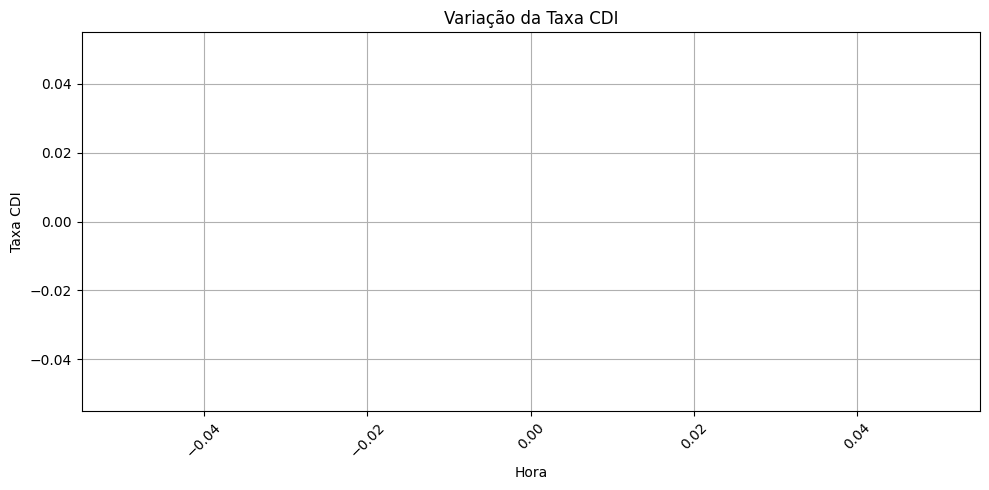

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lendo o CSV corretamente
df = pd.read_csv("taxa-cdi.csv", sep=",")
df.columns = df.columns.str.strip()  # remove espaços acidentais

# Verificando colunas
print("Colunas do CSV:", df.columns)
print(df.head())

# Extraindo hora e taxa
horas = df["hora"]
taxas = df["taxa"]

# Criando gráfico
plt.figure(figsize=(10,5))
plt.plot(horas, taxas, marker='o', linestyle='-')
plt.title("Variação da Taxa CDI")
plt.xlabel("Hora")
plt.ylabel("Taxa CDI")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Salvando gráfico
plt.savefig("grafico_cdi.png")
plt.show()


Iniciando extração da taxa CDI...
Extração concluída! Arquivo 'taxa-cdi.csv' criado.
Iniciando visualização...


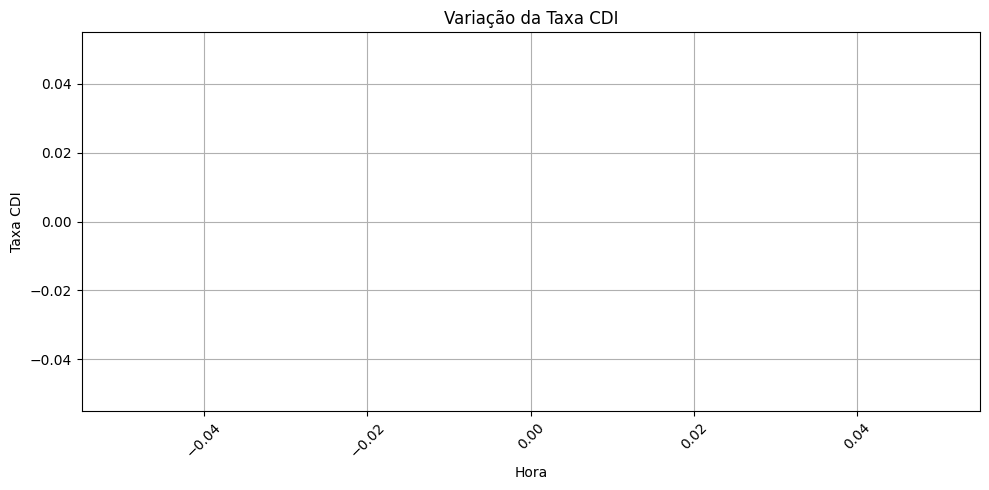

Gráfico salvo como '-f' e exibido acima!


In [ ]:
import os
import time
from random import random
from datetime import datetime
import requests
import json
import sys
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Verificando se o nome do gráfico foi passado
# ---------------------------------------------------
if len(sys.argv) < 2:
    print("Uso: python3 analise.py nome_do_grafico.png")
    sys.exit(1)

nome_grafico = sys.argv[1]

# ---------------------------------------------------
# 1) EXTRAÇÃO DA TAXA CDI
# ---------------------------------------------------
print("Iniciando extração da taxa CDI...")

URL = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.4389/dados?formato=json"

for _ in range(10):
    agora = datetime.now()
    data = agora.strftime("%Y/%m/%d")
    hora = agora.strftime("%H:%M:%S")

    try:
        response = requests.get(URL)
        response.raise_for_status()
        dados = json.loads(response.text)
        taxa = float(dados[-1]["valor"]) + (random() - 0.5)  # ruído leve
    except:
        taxa = None

    # Criar CSV se não existir
    if not os.path.exists("taxa-cdi.csv"):
        with open("taxa-cdi.csv", "w") as f:
            f.write("data,hora,taxa\n")

    # Salvar dados no CSV
    with open("taxa-cdi.csv", "a") as f:
        f.write(f"{data},{hora},{taxa}\n")

    time.sleep(1)  # pequena pausa

print("Extração concluída! Arquivo 'taxa-cdi.csv' criado.")

# ---------------------------------------------------
# 2) VISUALIZAÇÃO DA TAXA CDI
# ---------------------------------------------------
print("Iniciando visualização...")

# Lendo CSV
df = pd.read_csv("taxa-cdi.csv", sep=",")
df.columns = df.columns.str.strip()  # remove espaços acidentais
df = df.dropna(subset=["taxa"])      # remove linhas sem taxa

# Extraindo hora e taxa
horas = df["hora"]
taxas = df["taxa"]

# Criando gráfico
plt.figure(figsize=(10,5))
plt.plot(horas, taxas, marker='o', linestyle='-')
plt.title("Variação da Taxa CDI")
plt.xlabel("Hora")
plt.ylabel("Taxa CDI")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Salvando gráfico
plt.savefig(nome_grafico)
plt.show()

print(f"Gráfico salvo como '{nome_grafico}' e exibido acima!")
